<h1>CBIS-DDSM dataset exploration</h1>

<h2>Dependencies</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

<h2>Import metadata files</h2>

In [2]:
# Load the uploaded CSV files
calc_train_df = pd.read_csv('../data/processed/calc_training.csv')
calc_test_df = pd.read_csv('../data/processed/calc_test.csv')
mass_train_df = pd.read_csv('../data/processed/mass_training.csv')
mass_test_df = pd.read_csv('../data/processed/mass_test.csv')

<h2>Basic overview of the datasets</h2>

In [3]:
print("================= Calcification training set =================")
calc_train_df.info()
print("\n================= Calcification test set =================")
calc_test_df.info()
print("\n================= Masses training set =================")
mass_train_df.info()
print("\n================= Masses test set =================")
mass_test_df.info()

================= Calcification training set =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               326 non-null    object
 1   breast_density           326 non-null    int64 
 2   left or right breast     326 non-null    object
 3   image view               326 non-null    object
 4   abnormality id           326 non-null    int64 
 5   abnormality type         326 non-null    object
 6   calc type                322 non-null    object
 7   calc distribution        263 non-null    object
 8   assessment               326 non-null    int64 
 9   pathology                326 non-null    object
 10  subtlety                 326 non-null    int64 
 11  image file path          326 non-null    object
 12  cropped image file path  326 non-null    object
 13  ROI mask file path       326 non

<h2>Visualise value distribution</h2>

In [4]:
def visualise_distribution(df, columns, plt_title):
    for col in columns:
        plt.figure()
        df[col].value_counts(dropna=False).plot(kind='bar')
        plt.title(f'{plt_title}: {col} Distribution')
        plt.xlabel(col)
        plt.ylabel('Count')
        rotation_angle = 90 if len(df[col].value_counts()) > 10 else 30
        plt.xticks(rotation=rotation_angle)
        #plt.tight_layout()
        plt.show()

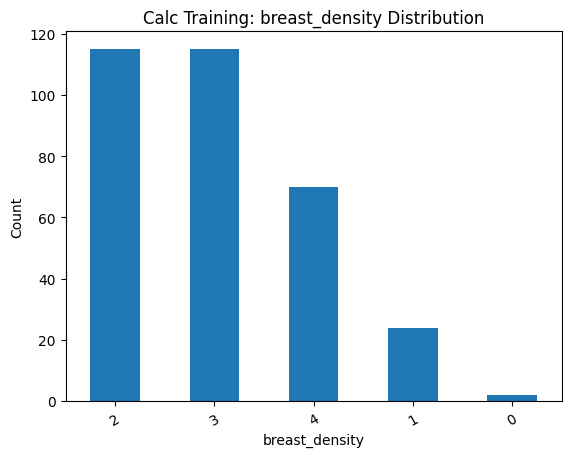

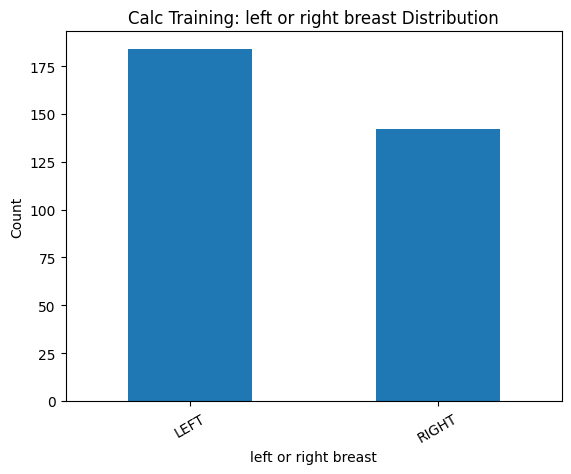

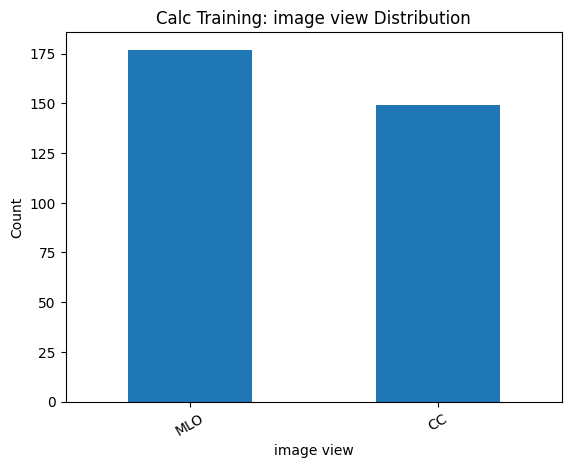

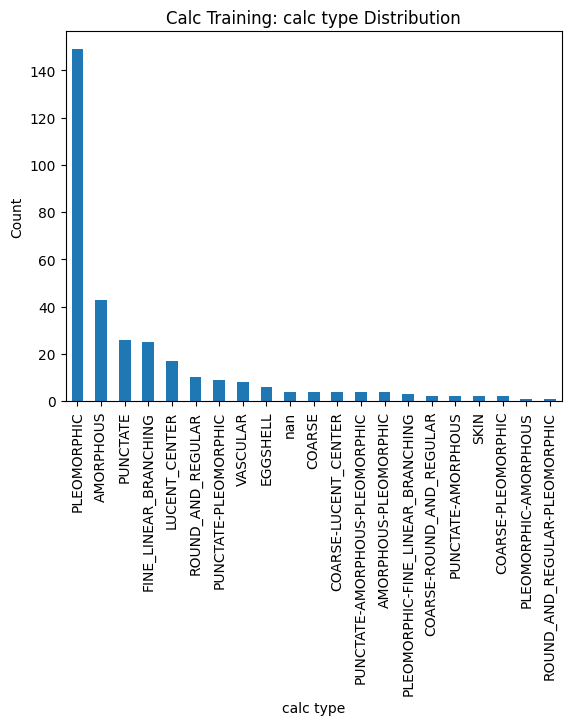

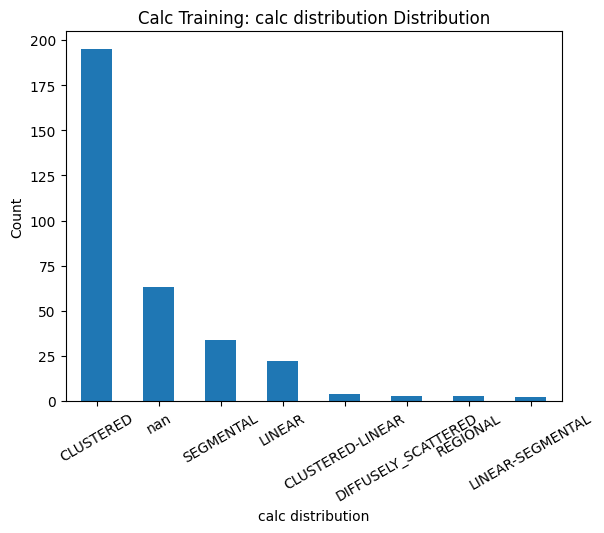

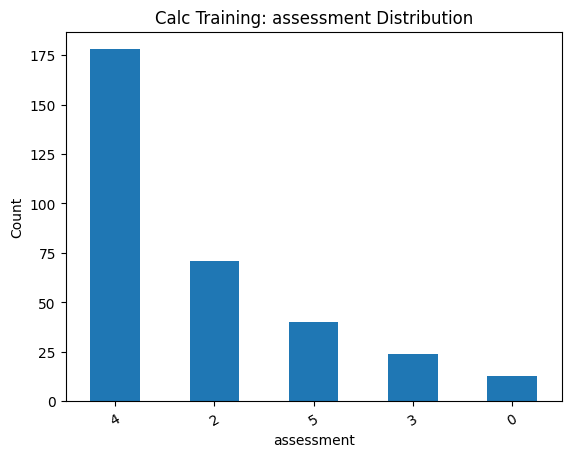

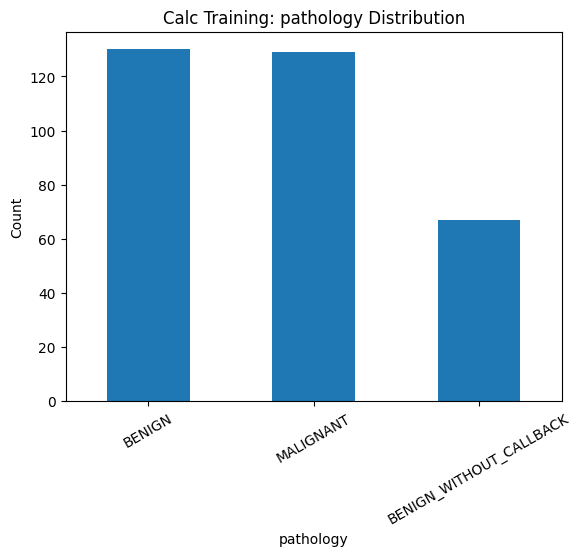

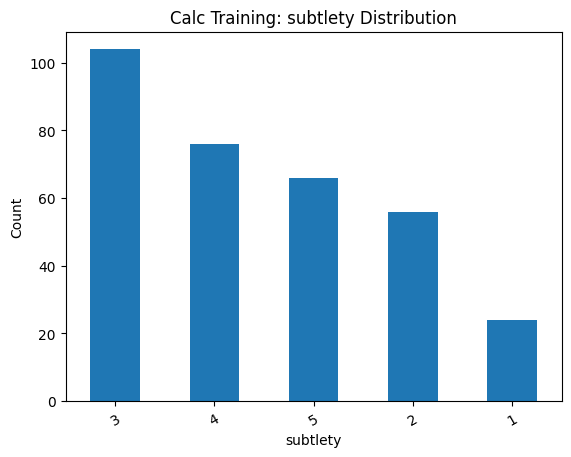

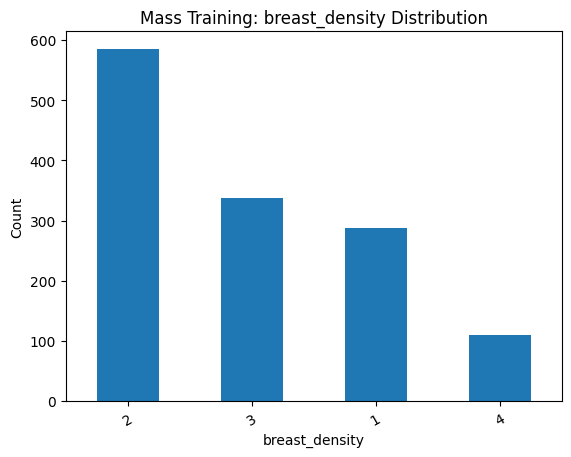

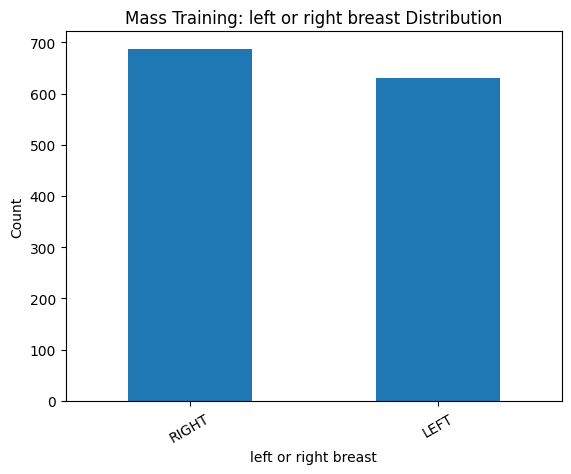

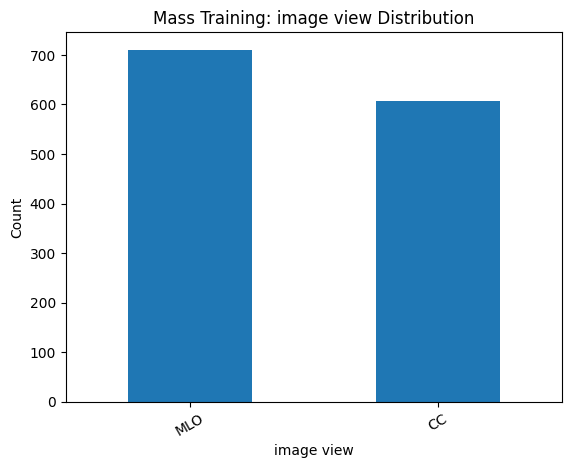

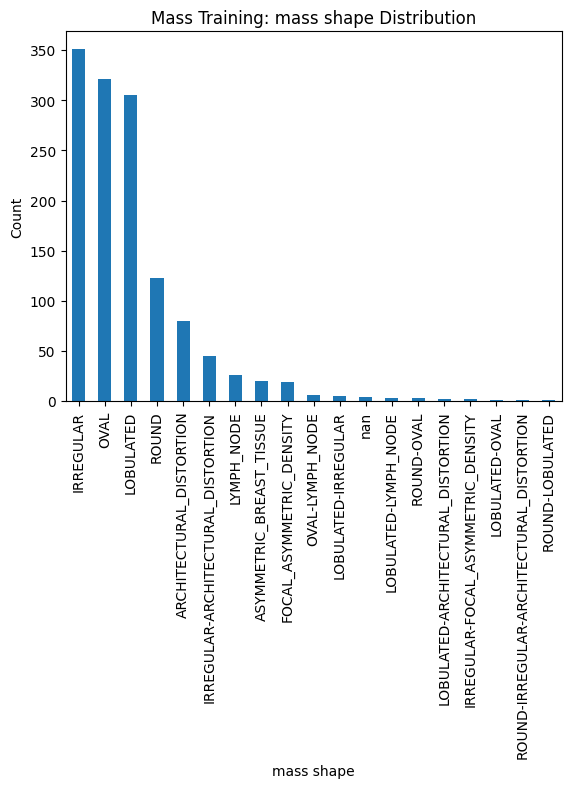

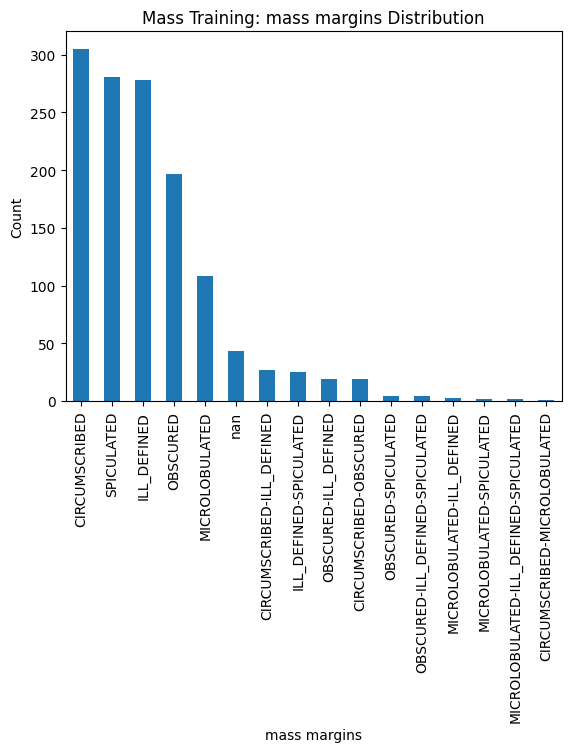

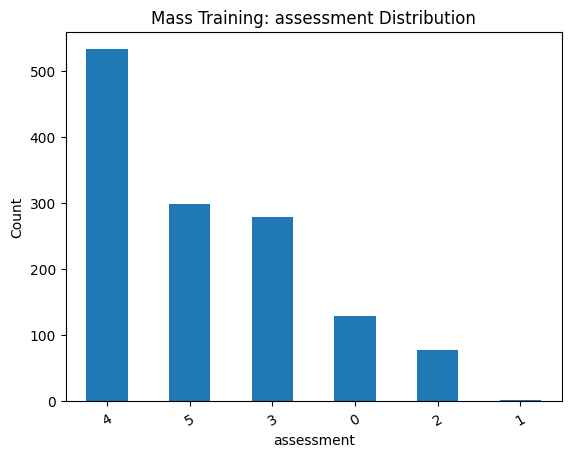

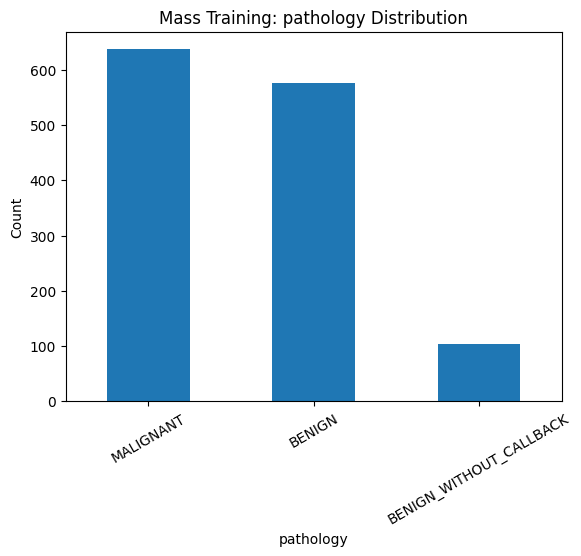

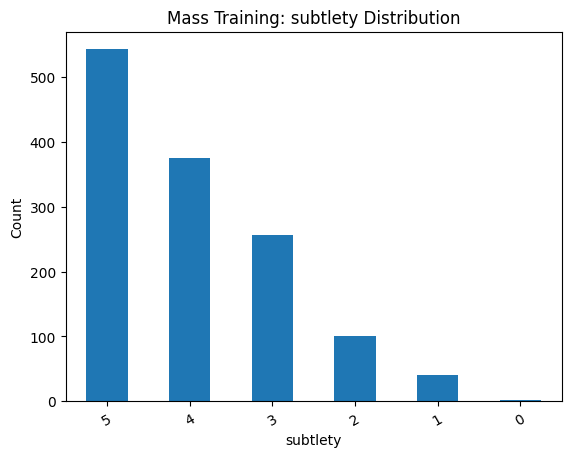

In [5]:
# Columns to explore 
calc_columns = ['breast_density', 'left or right breast', 'image view', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety']
mass_columns = ['breast_density', 'left or right breast', 'image view', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety']

# Plot distributions
visualise_distribution(calc_train_df, calc_columns, 'Calc Training')
visualise_distribution(mass_train_df, mass_columns, 'Mass Training')

<h2>Sample visualisation</h2>

In [6]:
!pip install pydicom


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pydicom
from PIL import Image
import numpy as np

In [8]:
# code adapted from https://github.com/nyukat/mammography_metarepository
def convert_dcm_image(file_in, greyscale_flag):

    #Read DICOM image into pixel arrays
    dcm = pydicom.dcmread(file_in, force = True)
    
    #ROI binary file
    if file_in.lower().endswith("-2.dcm"):

        pixel_array = dcm.pixel_array.astype(np.float32)

        # Save 8-bit binary
        binary_mask = (pixel_array > 0).astype(np.uint8) * 255
        img = Image.fromarray(binary_mask).resize((300, 300))
        
    #Mammogram
    else:
        image = dcm.pixel_array
        image = (image * 65535).astype(np.uint16)
        img = Image.fromarray(image).resize((300, 300))
    
    # Display  image
    plt.imshow(img, cmap='gray' if greyscale_flag else None)
    plt.axis('off')
    plt.title("Sample Image")
    plt.show()

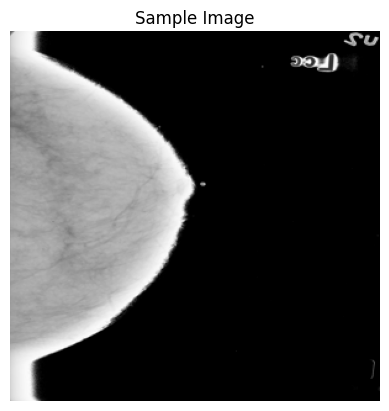

In [9]:
path = "../data/raw/CBIS-DDSM/Calc-Test_P_00038_RIGHT_CC/08-29-2017-DDSM-NA-28468/1.000000-full mammogram images-63304/1-1.dcm"

greyscale_flag = True
sample_full_img_mass =  convert_dcm_image(path, greyscale_flag)

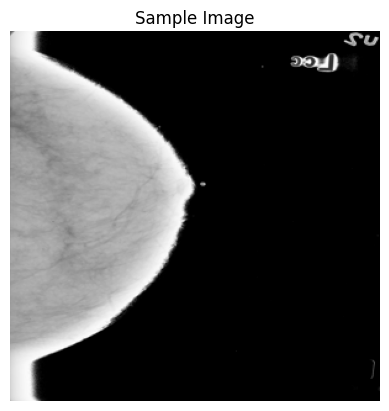

In [10]:
path = "../data/raw/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC/08-29-2017-DDSM-NA-96009/1.000000-full mammogram images-63992/1-1.dcm"

greyscale_flag = True
sample_full_img_mass =  convert_dcm_image(path, greyscale_flag)

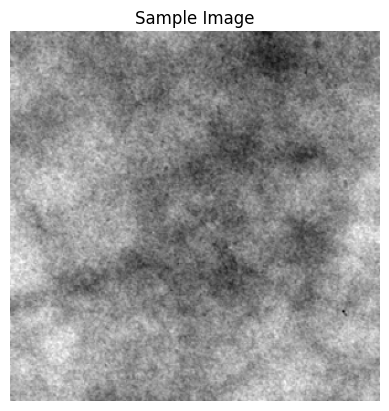

In [12]:
path = "../data/raw/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC_1/08-29-2017-DDSM-NA-94942/1.000000-ROI mask images-18515/1-1.dcm"

greyscale_flag = True
sample_full_img_mass =  convert_dcm_image(path, greyscale_flag)

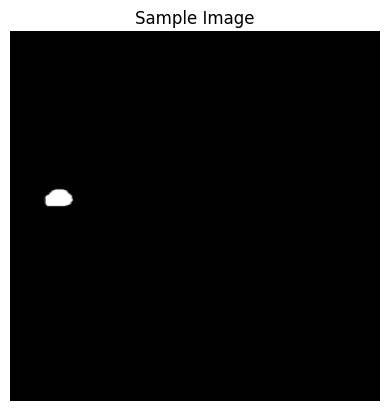

In [13]:
path = "../data/raw/CBIS-DDSM/Calc-Test_P_00038_LEFT_CC_1/08-29-2017-DDSM-NA-94942/1.000000-ROI mask images-18515/1-2.dcm"

greyscale_flag = True
sample_full_img_mass =  convert_dcm_image(path, greyscale_flag)